Data loaded successfully!

----- Model Comparison Results -----
Logistic Regression: 0.8921
Random Forest:       0.8932
XGBoost:             0.8956


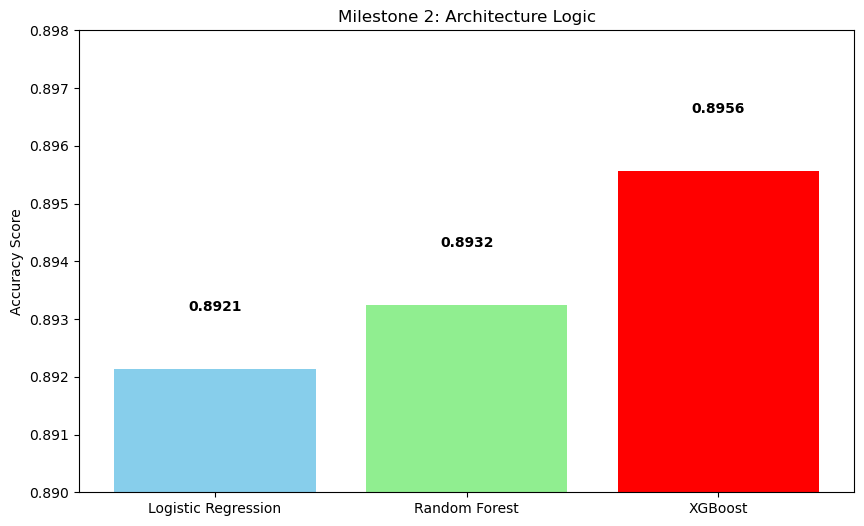

In [22]:
# Milestone 2 : Compare Logistic Regression, Random Forest and XGBoost
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier 
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 1. Load the data from Milestone 1
X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')

print("Data loaded successfully!")

# 2. Train Logistic Regression 
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_val, lr.predict(X_val))

# 3. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_val, rf.predict(X_val))

# 4. Train XGBoost 
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_acc = accuracy_score(y_val, xgb.predict(X_val))

# 5. Results Comparison
print(f"\n----- Model Comparison Results -----")
print(f"Logistic Regression: {lr_acc:.4f}")
print(f"Random Forest:       {rf_acc:.4f}") 
print(f"XGBoost:             {xgb_acc:.4f}")

# 6. Visualizing the Decision
models = ['Logistic Regression', 'Random Forest', 'XGBoost'] 
accuracies = [lr_acc, rf_acc, xgb_acc] 

plt.figure(figsize=(10, 6)) 
plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'red']) 
plt.ylabel('Accuracy Score')
plt.title('Milestone 2: Architecture Logic')

plt.ylim(0.89, 0.898) 

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()